In [24]:
# 패키지 (모듈) 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder

import pickle

In [25]:
# star-dataset.csv 파일의 데이터를 사용해서 star_type을 예측하는 모델 개발

In [26]:
# 데이터 확인
star_df = pd.read_csv('data/star-dataset.csv')

print( star_df.head() )
# print( star_df['Star type'].value_counts() )


   Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0             3068          0.002400        0.1700                   16.12   
1             3042          0.000500        0.1542                   16.60   
2             2600          0.000300        0.1020                   18.70   
3             2800          0.000200        0.1600                   16.65   
4             1939          0.000138        0.1030                   20.06   

   Star type Star color Spectral Class  
0          0        Red              M  
1          0        Red              M  
2          0        Red              M  
3          0        Red              M  
4          0        Red              M  


In [27]:
# 데이터 준비

X = star_df.drop(columns=['Star type'])
y = star_df['Star type']

In [28]:
# 데이터 확인 -> 결과 'Star color', 'Spectral Class' 컬럼은 숫자 인코딩 필요 -> OneHotEncoding 적용
X[:5]

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [29]:
# 데이터 전처리 : 범주형 데이터를 OneHotEncoding 처리

# 1. 범주형 데이터를 OneHotEncoding 한 후 데이터프레임으로 변환
ohe = OneHotEncoder()
# print( X.columns[-2:] )
encoded_data = ohe.fit_transform(X[X.columns[-2:]]).toarray()
encoded_df = pd.DataFrame(encoded_data, dtype='int')
encoded_df.head()

# 2. 나머지 컬럼으로 구성된 데이터프레임과 OneHotEncoding 한 데이터프레임을 병합 
X_encoded = pd.concat((X[X.columns[:-2]], encoded_df), axis=1)

X_encoded.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),0,1,2,3,4,5,...,16,17,18,19,20,21,22,23,24,25
0,3068,0.002400,0.1700,16.12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,3042,0.000500,0.1542,16.60,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2600,0.000300,0.1020,18.70,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,2800,0.000200,0.1600,16.65,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1939,0.000138,0.1030,20.06,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [30]:
# 데이터 준비 2 : 훈련 세트와 테스트 세트 분할
X_train, X_test, y_train, y_test = \
    train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
# 모델 준비 (생성)

# log_reg = LogisticRegression()
log_reg = LogisticRegression(max_iter=100000) # 성능 개선이 유지되는 동안 최대 반복 횟수 지정

In [32]:
# 모델 훈련 (학습)
# log_reg.fit(X_train, y_train) # 데이터프레임을 사용할 경우 컬럼명이 단순 숫자이면 오류 발생
log_reg.fit(X_train.values, y_train.values) # numpy array 형식으로 데이터 전달

c:\Users\human\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 12618 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100000
,multi_class,'deprecated'


In [33]:
# 모델 평가

log_reg.score(X_train.values, y_train.values), log_reg.score(X_test.values, y_test.values)

(0.9947916666666666, 1.0)

In [34]:
# 스케일 차이 확인
X_train.min().head(), X_train.max().head()

(Temperature (K)           1939.00000
 Luminosity(L/Lo)             0.00008
 Radius(R/Ro)                 0.00840
 Absolute magnitude(Mv)     -11.92000
 0                            0.00000
 dtype: float64,
 Temperature (K)            40000.00
 Luminosity(L/Lo)          849420.00
 Radius(R/Ro)                1948.50
 Absolute magnitude(Mv)        20.06
 0                              1.00
 dtype: float64)

In [35]:
# 모델 성능 개선을 위해 데이터 전처리 - 데이터 스케일링

mms = MinMaxScaler()
mms.fit(X_train.values)
X_train_scaled = mms.transform(X_train.values)
X_test_scaled = mms.transform(X_test.values)

X_train_scaled.min(), X_train_scaled.max()

(np.float64(0.0), np.float64(1.0000000000000002))

In [36]:
# 전처리한 데이터로 모델 생성 및 학습

log_reg2 = LogisticRegression(max_iter=10000)
log_reg2.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [37]:
# 모델 성능 평가 

log_reg2.score(X_train_scaled, y_train), log_reg2.score(X_test_scaled, y_test)

(0.9375, 0.875)

In [38]:
# 모델 성능 개선을 위해 규제 적용

scores = []
for c in [0.01, 0.1, 1, 10, 100, 1000, 10000]: # 규제 강도를 변경하면서 모델 성능 테스트
    log_reg3 = LogisticRegression(penalty='l2', C=c)
    log_reg3.fit(X_train_scaled, y_train)
    train_score, test_score = \
        log_reg3.score(X_train_scaled, y_train), log_reg3.score(X_test_scaled, y_test)
    scores.append( (c, train_score, test_score) )

scores

[(0.01, 0.71875, 0.6666666666666666),
 (0.1, 0.75, 0.6875),
 (1, 0.9375, 0.875),
 (10, 0.9947916666666666, 1.0),
 (100, 1.0, 1.0),
 (1000, 1.0, 0.9791666666666666),
 (10000, 1.0, 1.0)]

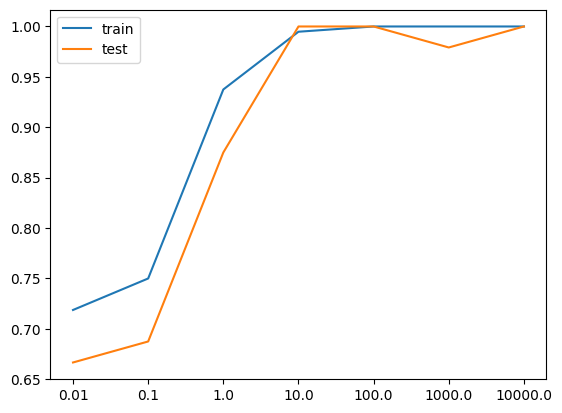

In [39]:
# 훈련 결과 시각화

scores_array = np.array(scores)
scores_array

scores_df = pd.DataFrame(scores, columns=['C', 'train_score', 'test_score'])
scores_df

plt.plot(scores_df['C'].astype('str'), scores_df['train_score'], label='train')
plt.plot(scores_df['C'].astype('str'), scores_df['test_score'], label='test')
plt.legend()
plt.show()

In [40]:
# 최적의 하이퍼 파라미터를 적용해서 최종 모델 훈련

final_log_reg = LogisticRegression(penalty='l2', C=100)

X_scaled = mms.transform(X_encoded.values)

final_log_reg.fit(X_scaled, y)

with open('models/star_log_reg_model.pickle', 'wb') as f:
    pickle.dump(final_log_reg, f)
